In [1]:
using Pkg
Pkg.activate("/Users/alia/Desktop/envs/ants")
using BifurcationKit
using Plots
using DifferentialEquations
using LaTeXStrings
using JLD2
using CSV
using DataFrames

  Activating project at `~/Desktop/envs/ants`


In [26]:
function model_7d(x,p)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma)=p
    S,B,C,T,xC,xB,xT = x
    H = 1 - S - B - C - T
    Sdot = (-(alphaC*(1+xC)+alphaB*(1+xB)+alphaT*(1+xT))*S) + gamma*H
        # + beta*T + (omegaC*C+omegaB*B)/(1+ (C/k)^n))
    Cdot = alphaC*(1+xC)*S - omegaC*C/(1+ (C/k)^n)
    Bdot = alphaB*(1+xB)*S - omegaB*B/(1+ (C/k)^n)
    Tdot = alphaT*(1+xT)*S - beta*T
    xCdot = 1/tau*(-xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C)))
    xBdot = 1/tau*(-xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C)))
    xTdot = 1/tau*(-xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C)))

    [
        Sdot
        Bdot
        Cdot
        Tdot
        xCdot
        xBdot
        xTdot
    ]
end

model_7d (generic function with 1 method)

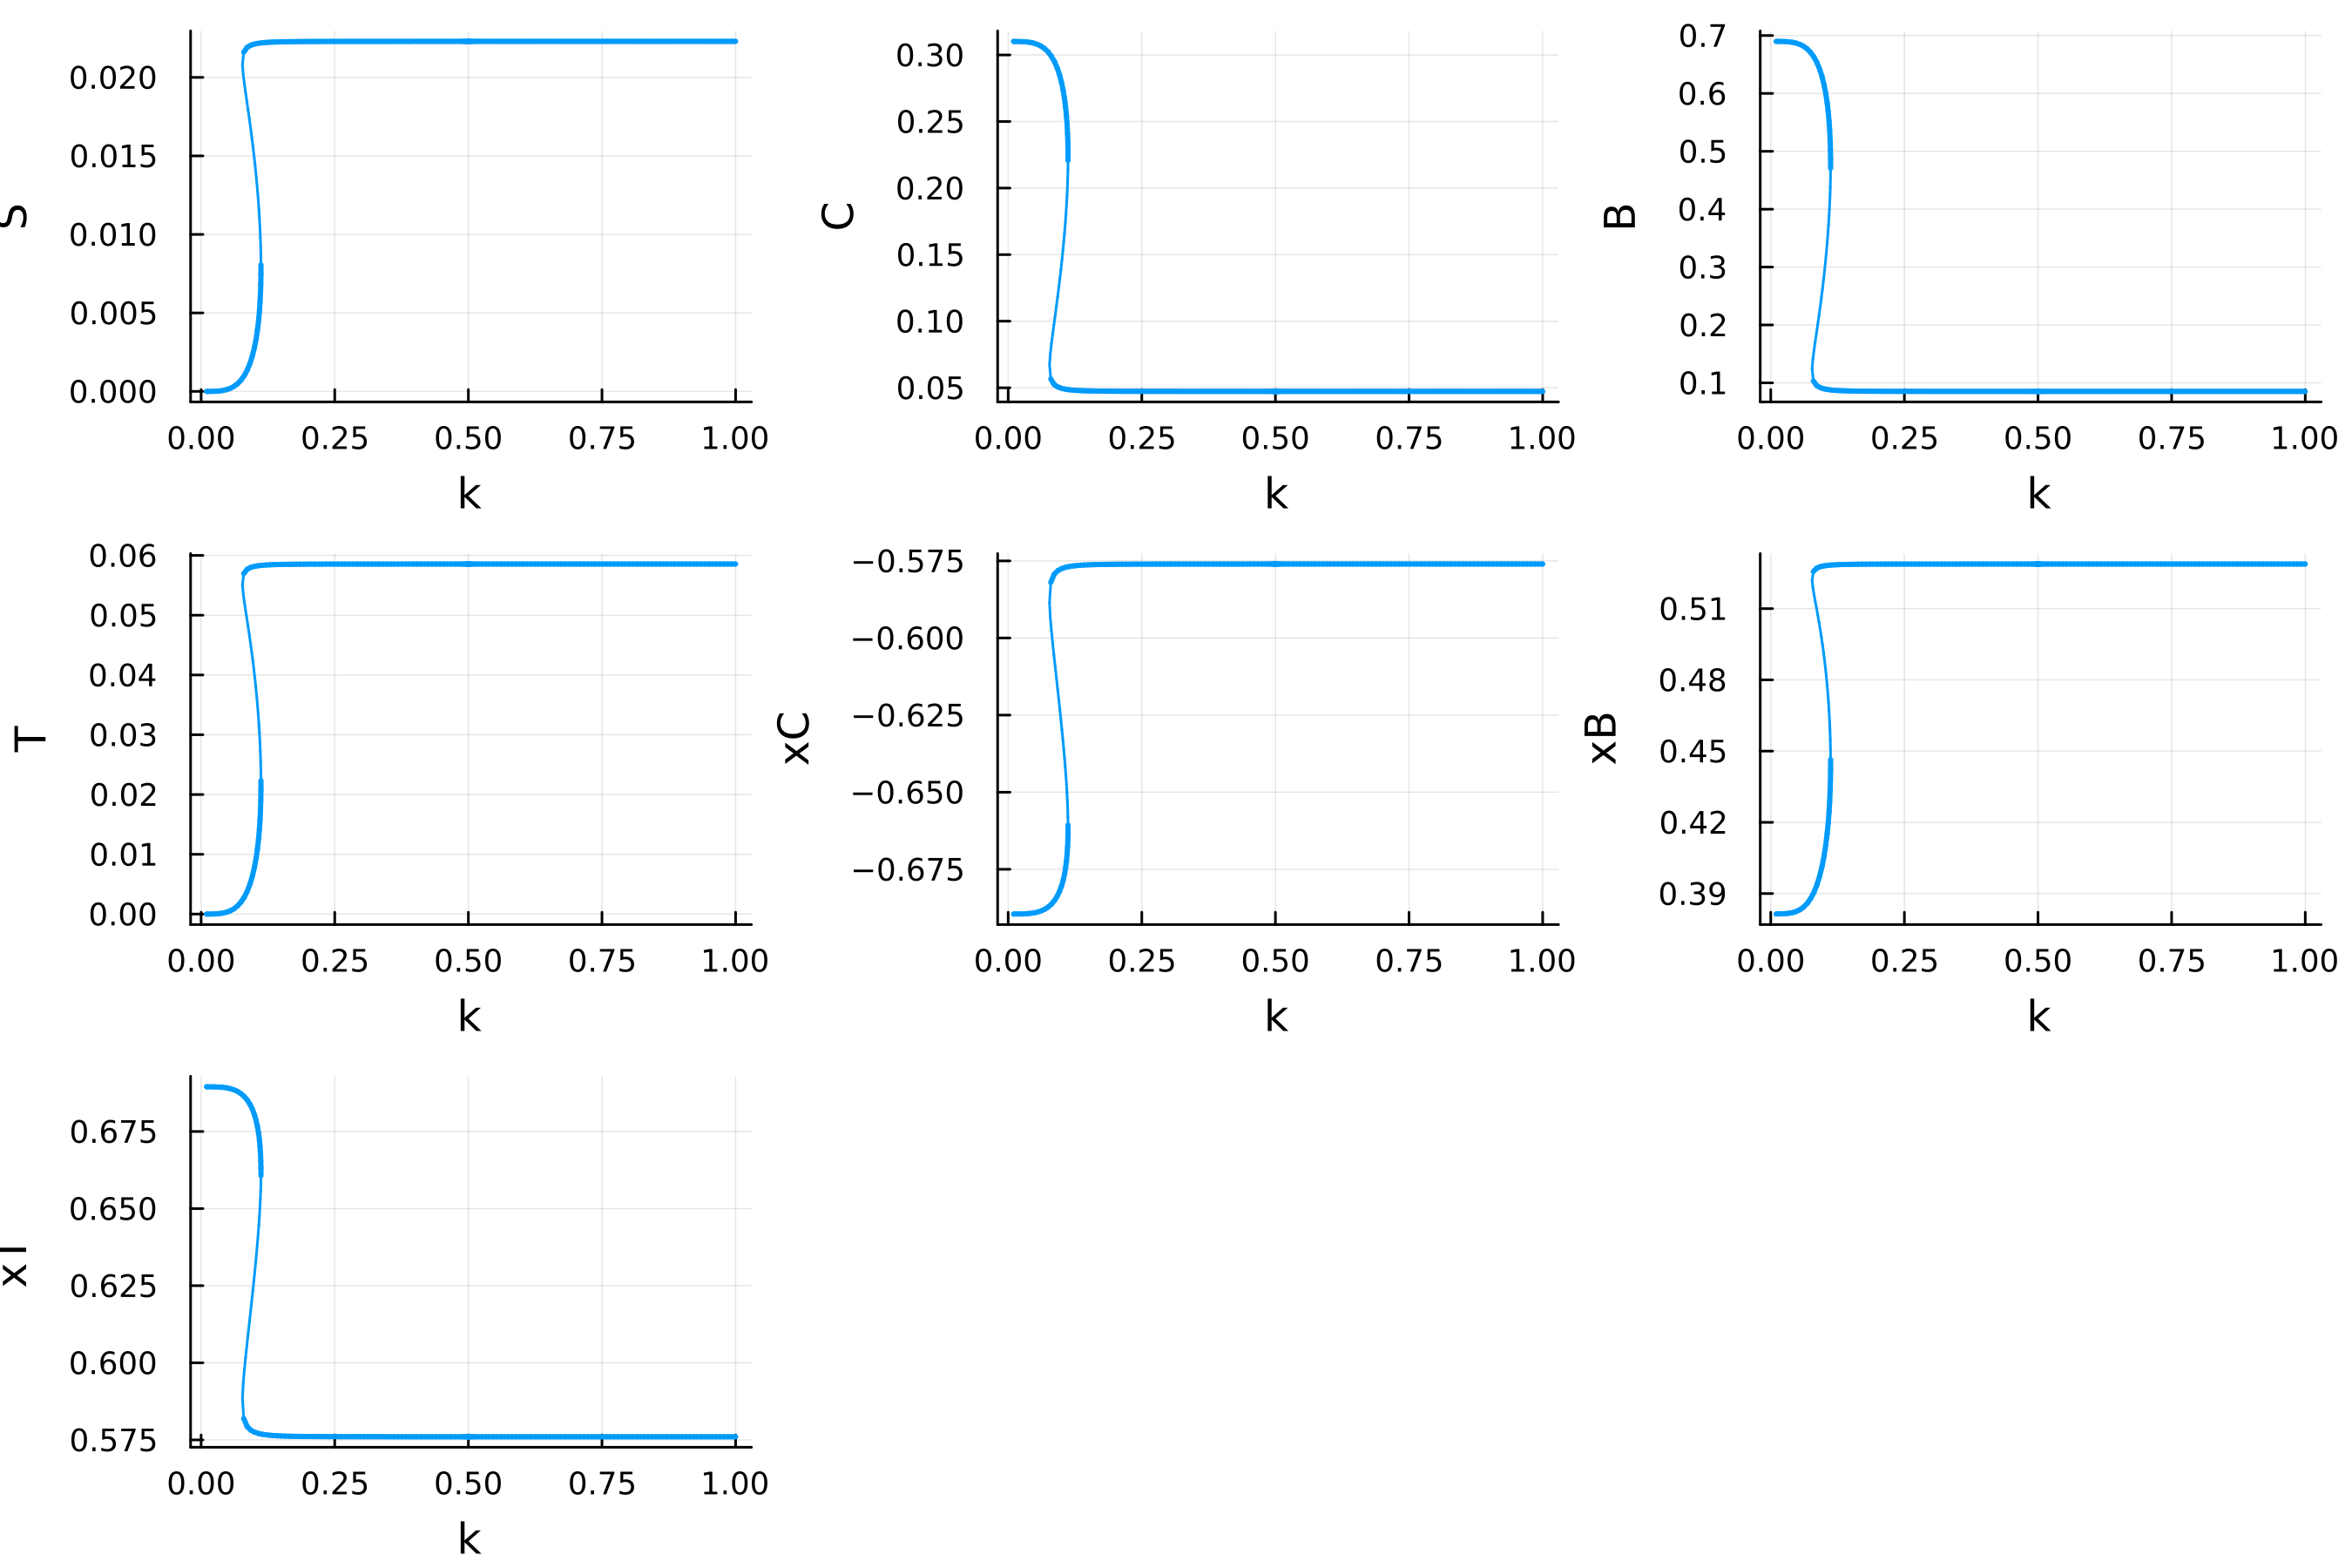

In [37]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
    k=0.5,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
    aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma = par

#u0 = [0.5,0.0,0.0,0.0,0.0,0.0,0.0]
u0=[0.124884391327275428,0.062413430071074756,0.12482655262389604,0.04150013222529302,-0.0006304423107703057,-0.0006278899118493966,0.0006304423107703055]

u_bif_problem = BifurcationProblem(model_7d, u0, par, (@optic _.k),
               record_from_solution = (x, p; k...) -> (S = x[1], B = x[2], C = x[3], T = x[4], xC=x[5],xB=x[6],xT=x[7]))

opts_br = ContinuationPar(
    p_min = 0.01, p_max = 1.0,
    ds = 1e-5,
    dsmax = 5e-3,
    dsmin = 1e-6,
    detect_bifurcation = 1,
    n_inversion = 8,

    newton_options = NewtonPar(
        tol = 1e-8,
        max_iterations = 100,
        verbose = false
    ),
    tol_stability = 1e-8,
)

u_branch_equilibria = continuation(u_bif_problem, PALC(),opts_br,bothside=true)

p1=plot(u_branch_equilibria,vars = (:param,:S))
p2 =plot(u_branch_equilibria,vars = (:param,:C))
p3=plot(u_branch_equilibria,vars = (:param,:B))
p4= plot(u_branch_equilibria,vars = (:param,:T))
p5= plot(u_branch_equilibria,vars = (:param,:xC))
p6= plot(u_branch_equilibria,vars = (:param,:xB))
p7= plot(u_branch_equilibria,vars = (:param,:xT))
FIG = plot(p1,p2,p3,p4,p5,p6,p7,layout = 7,size = (900,600),dpi=300)

In [28]:
diagram = bifurcationdiagram(u_bif_problem,PALC(),
	4,
	opts_br,bothside = true
	)

┌ Error: Failure to converge with given tolerance = 1.0e-8.
│ Step = 37
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 1.0e-6.
│ Stopping continuation at continuation step 37.
└ @ BifurcationKit /Users/alia/.julia/packages/BifurcationKit/sliaw/src/continuation/Contbase.jl:73
┌ Error: Failure to converge with given tolerance = 1.0e-8.
│ Step = 33
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 1.0e-6.
│ Stopping continuation at continuation step 33.
└ @ BifurcationKit /Users/alia/.julia/packages/BifurcationKit/sliaw/src/continuation/Contbase.jl:73


[Bifurcation diagram]
 ┌─ From 0-th bifurcation point.
 ├─ Number of children: 0
 └─ Root (recursion level 1)
      ┌─ Curve type: EquilibriumCont
      ├─ Number of points: 72
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter gamma starts at 0.09999999999952791, ends at 0.10000000000047217
      ├─ Algo: PALC [Secant]
      └─ Special points:

- #  1, endpoint at gamma ≈ +0.10000000,                                                                     step =   0
- #  2, endpoint at gamma ≈ +0.10000000,                                                                     step =  71


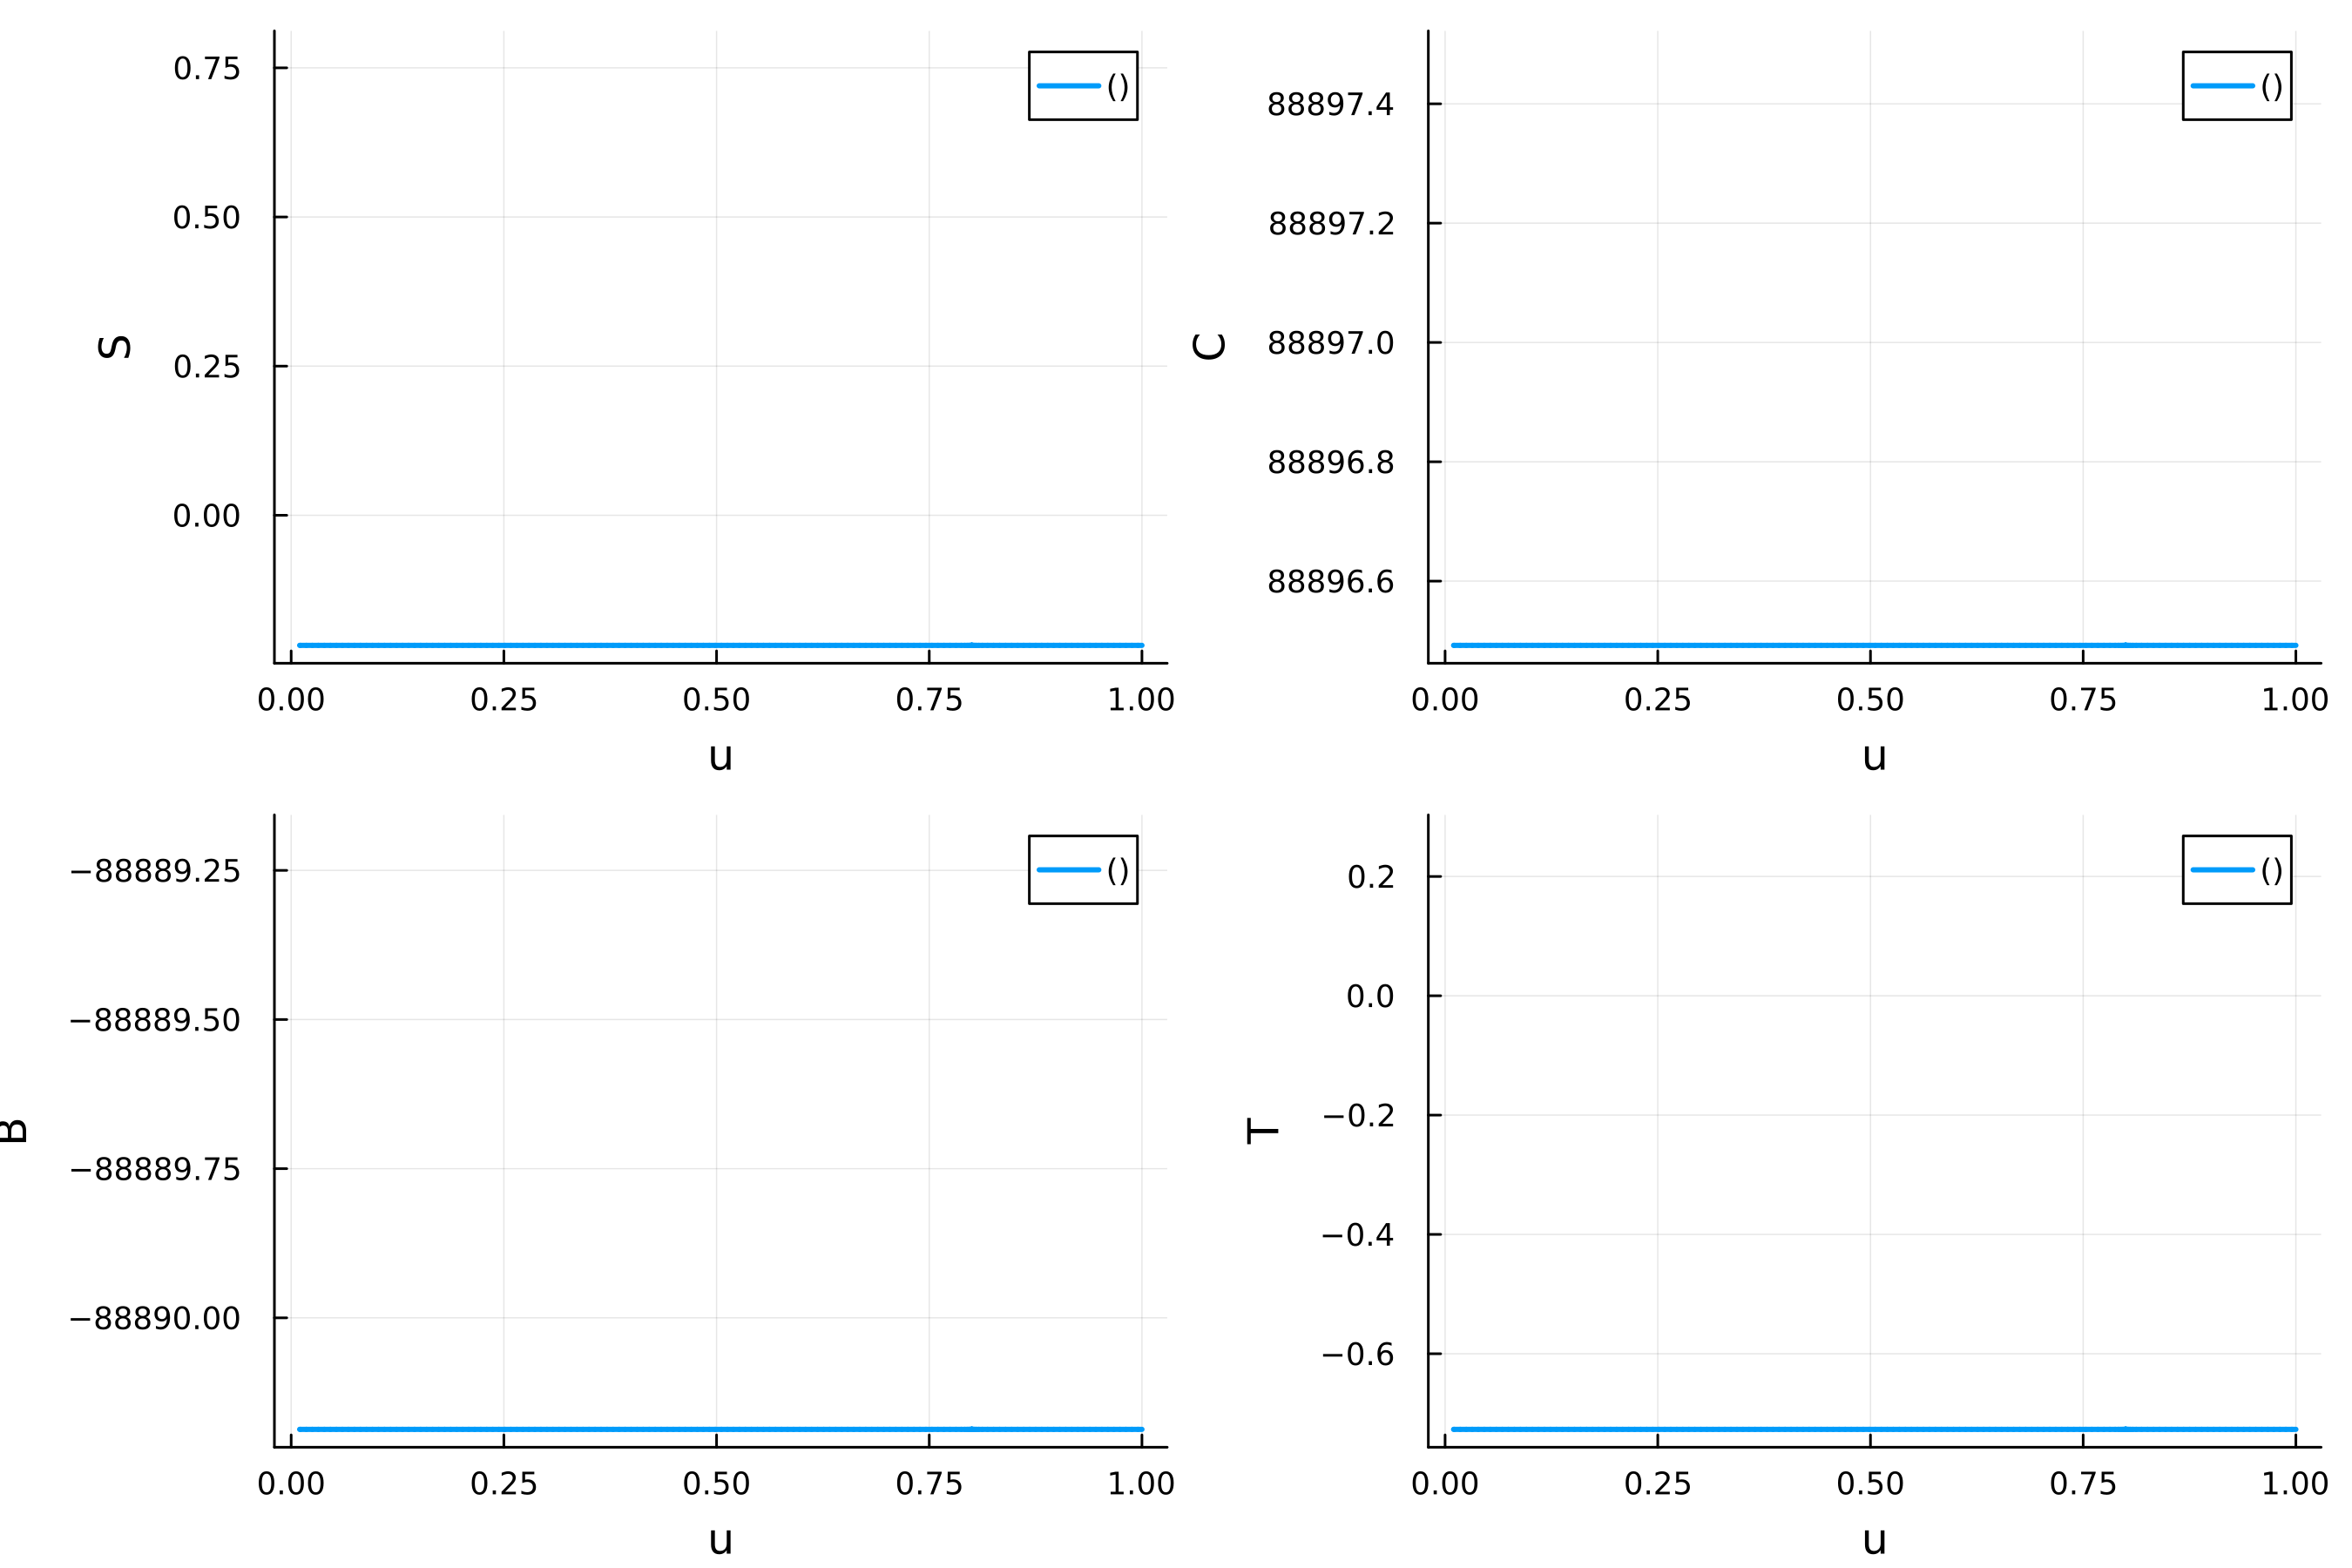

In [23]:
p1=plot(diagram,vars = (:param,:S))
p2 =plot(diagram,vars = (:param,:C))
p3=plot(diagram,vars = (:param,:B))
p4= plot(diagram,vars = (:param,:T))
FIG = plot(p1,p2,p3,p4, layout = 4,size = (900,600),dpi=300)